# Datos Faltantes

In [1]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.impute import SimpleImputer, KNNImputer
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Cargar el conjunto de datos
diabetes = load_diabetes(as_frame=True)
data = diabetes.data
data['target'] = diabetes.target

In [3]:
data.sample(10)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
86,-0.070900,0.050680,-0.075186,-0.040099,-0.051103,-0.015092,-0.039719,-0.002592,-0.096435,-0.034215,55.0
380,0.016281,-0.044642,0.026128,0.058608,-0.060735,-0.044215,-0.013948,-0.033958,-0.051404,-0.025930,52.0
244,-0.060003,0.050680,0.054152,-0.019442,-0.049727,-0.048912,0.022869,-0.039493,-0.043984,-0.005220,187.0
115,-0.030942,0.050680,0.001339,-0.005670,0.064477,0.049416,-0.047082,0.108111,0.083799,0.003064,229.0
260,0.041708,-0.044642,-0.008362,-0.057313,0.008063,-0.031376,0.151726,-0.076395,-0.080237,-0.017646,39.0
427,-0.034575,0.050680,0.005650,-0.005670,-0.073119,-0.062691,-0.006584,-0.039493,-0.045424,0.032059,67.0
103,0.059871,0.050680,0.041218,0.011544,0.041086,0.070710,-0.036038,0.034309,-0.010903,-0.030072,198.0
374,-0.107226,-0.044642,-0.034229,-0.067642,-0.063487,-0.070520,0.008142,-0.039493,-0.000612,-0.079778,140.0
9,-0.070900,-0.044642,0.039062,-0.033213,-0.012577,-0.034508,-0.024993,-0.002592,0.067737,-0.013504,310.0
351,-0.085430,0.050680,-0.040696,-0.033213,-0.081374,-0.069580,-0.006584,-0.039493,-0.057803,-0.042499,71.0


In [4]:
# Simular valores faltantes
np.random.seed(42)
data.loc[data.sample(frac=0.1).index, 'bmi'] = np.nan
data.loc[data.sample(frac=0.1).index, 'bp'] = np.nan

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado:

### 1. ¿Cuántos valores faltantes hay en cada columna?**

In [5]:
data.isnull().sum()


age        0
sex        0
bmi       44
bp        44
s1         0
s2         0
s3         0
s4         0
s5         0
s6         0
target     0
dtype: int64

### 2. Utiliza imputación simple (media) para llenar los valores faltantes de la columna 'bmi'.

In [7]:
# Crear el imputador usando la media
imputador_media = SimpleImputer(strategy='mean')

# Aplicarlo solo a la columna 'bmi'
data['bmi'] = imputador_media.fit_transform(data[['bmi']])


In [8]:
data.isnull().sum()


age        0
sex        0
bmi        0
bp        44
s1         0
s2         0
s3         0
s4         0
s5         0
s6         0
target     0
dtype: int64

### 3. Utiliza KNNImputer para imputar valores en las columnas 'bmi' y 'bp'. Compara los resultados con los de la imputación simple.

In [9]:
# Volver a simular valores faltantes
np.random.seed(42)
data.loc[data.sample(frac=0.1).index, 'bmi'] = np.nan
data.loc[data.sample(frac=0.1).index, 'bp'] = np.nan


In [10]:
# Crear imputador KNN
imputador_knn = KNNImputer(n_neighbors=5)

# Aplicarlo a las columnas 'bmi' y 'bp'
data[['bmi', 'bp']] = imputador_knn.fit_transform(data[['bmi', 'bp']])


In [11]:
data.isnull().sum()


age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

### 4. Genera un histograma comparando los datos antes y después de la imputación en la columna 'bmi'.

In [12]:
np.random.seed(42)
data.loc[data.sample(frac=0.1).index, 'bmi'] = np.nan


In [13]:
data_before = data.copy()


In [14]:
imputador_knn = KNNImputer(n_neighbors=5)
data[['bmi']] = imputador_knn.fit_transform(data[['bmi']])


In [15]:
data_after = data.copy()


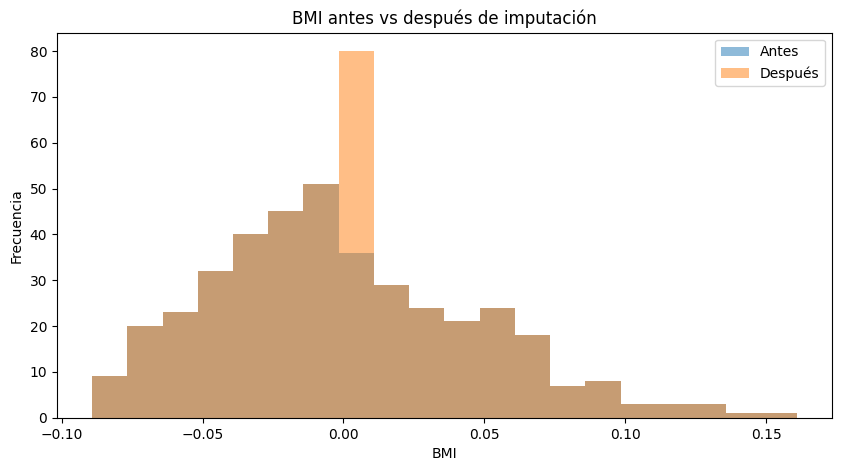

In [16]:
plt.figure(figsize=(10,5))

plt.hist(data_before['bmi'], bins=20, alpha=0.5, label='Antes')
plt.hist(data_after['bmi'], bins=20, alpha=0.5, label='Después')

plt.legend()
plt.title('BMI antes vs después de imputación')
plt.xlabel('BMI')
plt.ylabel('Frecuencia')
plt.show()
